# Running a baroclinic instability test case

First we set up the mpi environment:

In [1]:
import ipyparallel as ipp
ntiles = 6
layout = (1, 1)

num_ranks = ntiles * layout[0] * layout[1]
cluster = ipp.Cluster(engines="mpi", n=num_ranks).start_and_connect_sync()

# start executing cells on the workers in parallel from here on
%autopx

Starting 6 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>
100%|███████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.10engine/s]
%autopx enabled


[3:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[6], line 1
----> 1 get_ipython().run_cell_magic('time', '', 'try:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File /usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2572, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2570 with self.builtin_trap:
   2571     args = (magic_arg_s, cell)
-> 2572     result = fn(*args, **kwargs)
   2574 # The code below prevents the output from being displayed
   2575 # when using magics with decorator @output_can_be_silenced
   2576 # when the last Python token in the expression is a ';'.
   2577 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /usr/local/lib/python3.12/site-packages/IPython/core/magics/execution.py:1447, in ExecutionMagics.time(self, line, cell, local_ns)
   1445 if interrupt_occured:
   1446  

[0:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[6], line 1
----> 1 get_ipython().run_cell_magic('time', '', 'try:\n    driver.step_all()\nfinally:\n    driver.cleanup()\n')

File /usr/local/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2572, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2570 with self.builtin_trap:
   2571     args = (magic_arg_s, cell)
-> 2572     result = fn(*args, **kwargs)
   2574 # The code below prevents the output from being displayed
   2575 # when using magics with decorator @output_can_be_silenced
   2576 # when the last Python token in the expression is a ';'.
   2577 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /usr/local/lib/python3.12/site-packages/IPython/core/magics/execution.py:1447, in ExecutionMagics.time(self, line, cell, local_ns)
   1445 if interrupt_occured:
   1446  

[0:execute]
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[18], line 4
      2 print(driver.state.radiation_state.tlyr.field.min())
      3 print(driver.state.radiation_state.prsi.field.min())
----> 4 plt.semilogy(driver.state.radiation_state.tlyr.field[3,3,:], driver.state.radiation_state.prsi.field[3,3,:])

File /usr/local/lib/python3.12/site-packages/matplotlib/pyplot.py:3970, in semilogy(*args, **kwargs)
   3968 @_copy_docstring_and_deprecators(Axes.semilogy)
   3969 def semilogy(*args, **kwargs) -> list[Line2D]:
-> 3970     return gca().semilogy(*args, **kwargs)

File /usr/local/lib/python3.12/site-packages/matplotlib/axes/_axes.py:2012, in Axes.semilogy(self, *args, **kwargs)
   2008 d = {k: v for k, v in kwargs.items()
   2009      if k in ['base', 'subs', 'nonpositive',
   2010               'basey', 'subsy', 'nonposy']}
   2011 self.set_yscale('log', **d)
-> 2012 re

Double-check the MPI setup:

In [2]:
from mpi4py import MPI

mpi_comm = MPI.COMM_WORLD
mpi_size = mpi_comm.Get_size()
mpi_rank = mpi_comm.Get_rank()

print(f"I am MPI-rank {mpi_rank} of a total of {mpi_size}")

[stdout:0] I am MPI-rank 0 of a total of 6


[stdout:3] I am MPI-rank 3 of a total of 6


[stdout:5] I am MPI-rank 5 of a total of 6


[stdout:4] I am MPI-rank 4 of a total of 6


[stdout:1] I am MPI-rank 1 of a total of 6


[stdout:2] I am MPI-rank 2 of a total of 6


Next we set up the model driver using the yaml config file:

In [3]:
%%time

from pace import Driver, DriverConfig
import yaml

config_file = "baroclinic_c20.yaml"

with open(config_file, "r") as f:
    driver_config = DriverConfig.from_dict(yaml.safe_load(f))
driver = Driver(config=driver_config)

[output:3]

[output:5]

[output:0]

[output:1]

[output:2]

...

[stderr:2] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/ndsl/grid/gnomonic.py:681: RuntimeWarning: invalid value encountered in divide
  np.sum(p * q, axis=-1) / np.sqrt(np.sum(p**2, axis=-1) * np.sum(q**2, axis=-1))
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.

[stderr:0] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt__fa8_157_25` may be 

[stderr:1] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt__fa8_157_25` may be 

[stderr:4] /usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `p_ref` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `rf` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `dmdir` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `coszenm` may be uninitialized.
  result = step(result)
/usr/local/lib/python3.12/site-packages/gt4py/cartesian/gtc/passes/gtir_pipeline.py:48: UserWarning: `zt__fa8_157_25` may be 

%px: 100%|███████████████████████████████████████████████████████████████████| 6/6 [03:11<00:00, 31.85s/tasks]


In [4]:
if mpi_rank == 0:
    print(driver.state.grid_data.lon_agrid.shape)

[stdout:0] (27, 27)


We can inspect the initial model state:

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs
from fv3viz import pcolormesh_cube
from ndsl import CubedSphereCommunicator

communicator = CubedSphereCommunicator.from_layout(
    comm=driver.comm,
    layout=driver.config.layout,
)
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)

[output:0]

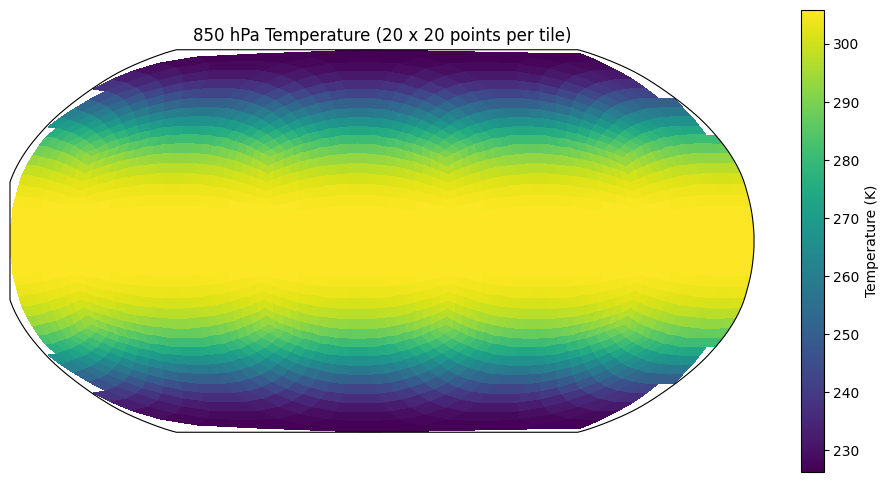

In [6]:
if mpi_rank == 0:
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    
    nx = temperature.shape[1]
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"850 hPa Temperature ({nx} x {nx} points per tile)")
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         surface_pressure.data[:, :, :]/100.,
#         cmap="viridis",
#     )
#     plt.colorbar(f1, label="Surface Pressure (hPa)")
#     ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
#     fig = plt.figure(figsize=(12, 6))
#     ax = fig.add_subplot(111, projection=ccrs.Robinson())
#     f1 = pcolormesh_cube(
#         grid_lat.data * 180./np.pi,
#         grid_lon.data * 180./np.pi,
#         u_mean[:,:,:,65],
#         cmap="bwr",
#     )
#     plt.colorbar(f1, label="U wind (m/s)")
#     ax.set_title(f"U Wind ({nx} x {nx} points per tile)")

And then we can run the model:

In [7]:
%%time
try:
    driver.step_all()
finally:
    driver.cleanup()

[stdout:4] 2026-02-26 16:18:23|INFO|rank 4|ndsl.logging:integrating driver forward in time
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 4|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 

[stdout:5] 2026-02-26 16:18:23|INFO|rank 5|ndsl.logging:integrating driver forward in time
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 5|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 

[stdout:1] 2026-02-26 16:18:23|INFO|rank 1|ndsl.logging:integrating driver forward in time
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 1|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 

[stdout:2] 2026-02-26 16:18:23|INFO|rank 2|ndsl.logging:integrating driver forward in time
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 2|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 

[stdout:3] 2026-02-26 16:18:23|INFO|rank 3|ndsl.logging:integrating driver forward in time
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 3|ndsl.logging:Quantity `cxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 

[stdout:0] 2026-02-26 16:18:23|INFO|rank 0|ndsl.logging:integrating driver forward in time
2026-02-26 16:18:23|INFO|rank 0|ndsl.logging:FV Setup
2026-02-26 16:18:23|INFO|rank 0|ndsl.logging:Adjust pt
2026-02-26 16:18:23|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 0|ndsl.logging:Quantity `q_in` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|INFO|rank 0|ndsl.logging:DynCore
2026-02-26 16:18:23|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis i_interface: 21 < 26.
2026-02-26 16:18:23|WARNING|rank 0|ndsl.logging:Quantity `mfxd` is too small for the targeted domain in axis j: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis i: 20 < 26.
2026-02-26 16:18:23|WARNING|rank 0|ndsl.logging:Quantity `mfyd` is too small for the targeted domain in axis j_interface: 21 < 26.
2

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
NotebookApp.rate_limit_window=3.0 (secs)



%px: 100%|███████████████████████████████████████████████████████████████████| 6/6 [00:47<00:00,  7.94s/tasks]


AlreadyDisplayedError: 6 errors

Now let's investigate the model state

In [8]:
u_wind = communicator.gather(driver.state.dycore_state.u)
temperature = communicator.gather(driver.state.dycore_state.pt)
surface_pressure = communicator.gather(driver.state.dycore_state.ps)
grid_lon = communicator.gather(driver.state.grid_data.lon)
grid_lat = communicator.gather(driver.state.grid_data.lat)
a_lon = communicator.gather(driver.state.grid_data.lon_agrid)
a_lat = communicator.gather(driver.state.grid_data.lat_agrid)
qvap = communicator.gather(driver.state.dycore_state.qvapor)
qcld = communicator.gather(driver.state.dycore_state.qcld)
qrain = communicator.gather(driver.state.dycore_state.qrain)
surface_temperature = communicator.gather(driver.state.sfc_state.tsfc)

In [9]:
from dataclasses import InitVar, dataclass, field, fields
import ndsl.dsl.gt4py_utils as gt_utils

[stdout:0] False
False
[3.71151327e-06 3.96123516e-06 4.25308963e-06 4.57602339e-06
 4.92259437e-06 5.29324487e-06 5.69398038e-06 6.13698327e-06
 6.63966669e-06 7.22549864e-06 7.91918266e-06 8.74450353e-06
 9.72189637e-06 9.36977405e-06 1.07866291e-05 8.67087033e-06
 7.15947177e-06 6.52769828e-06 6.51227544e-06 7.01013602e-06
 8.00931787e-06 9.54811259e-06 1.16802225e-05 1.43705943e-05
 1.76062139e-05 2.18055630e-05 2.82594706e-05 3.82890877e-05
 5.27637067e-05 7.42558044e-05 1.07190949e-04 1.81258008e-04
 2.75482567e-04 3.59676188e-04 4.39371973e-04 5.23891932e-04
 6.33156013e-04 7.67039628e-04 9.26260062e-04 1.11446160e-03
 1.33547488e-03 1.59325186e-03 1.89175603e-03 2.23476745e-03
 2.62591275e-03 3.06832186e-03 3.56458478e-03 4.11638324e-03
 4.72504725e-03 5.38857627e-03 6.03420435e-03 6.52629062e-03
 7.02567520e-03 7.52865891e-03 8.03075462e-03 8.52742913e-03
 9.01436277e-03 9.48740032e-03 9.94275356e-03 1.03770941e-02
 1.07872833e-02 1.11707269e-02 1.15252058e-02 1.18479740e-02
 

[output:0]

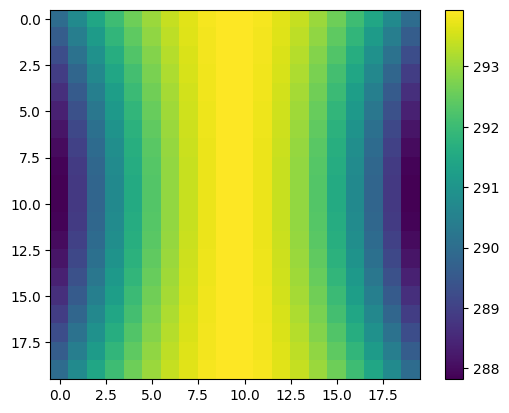

In [10]:
if mpi_rank == 0:
    print(np.all(np.isnan(driver.physics._sfc._fh2.field[:])))
    print(np.all(np.isnan(driver.state.physics_state.delp.field[:])))
    print(driver.state.physics_state.qvapor.field[5,5,:])
#     print(driver.state.dycore_state.ua.field[5,5,:])
    print(driver.physics._qvapor1.field[5,5,:])
    print(driver.physics._hydro_delp)
    print(np.any(driver.state.sfc_state.phil.field==0))
    print(driver.state.sfc_state.prslk.field.max())
#     print(driver.state.sfc_state.hflx.field)
#     print(driver.state.physics_state.tsfc.field[:])
#     print(driver.physics._prescribe_sst)
#     plt.imshow(driver.state.sfc_state.zorl.field[:]/9.81)
    nans = []
    zeros = []
    for _field in fields(driver.state.sfc_state):
        if "dims" in _field.metadata.keys():
            arr = gt_utils.asarray(getattr(driver.state.sfc_state, _field.name).data)
            if np.any(np.isnan(arr)):
                nans.append(_field.name)
                print(f"NaNs in {_field.name}")
            if np.all(arr==0.0):
                zeros.append(_field.name)
    print("nans:", nans)
    print("zeros:", zeros)
    print(np.all(driver.state.radiation_state.mu0.field==0))
    plt.imshow(driver.state.sfc_state.tsfc.field[:])
    plt.colorbar()

[output:0]

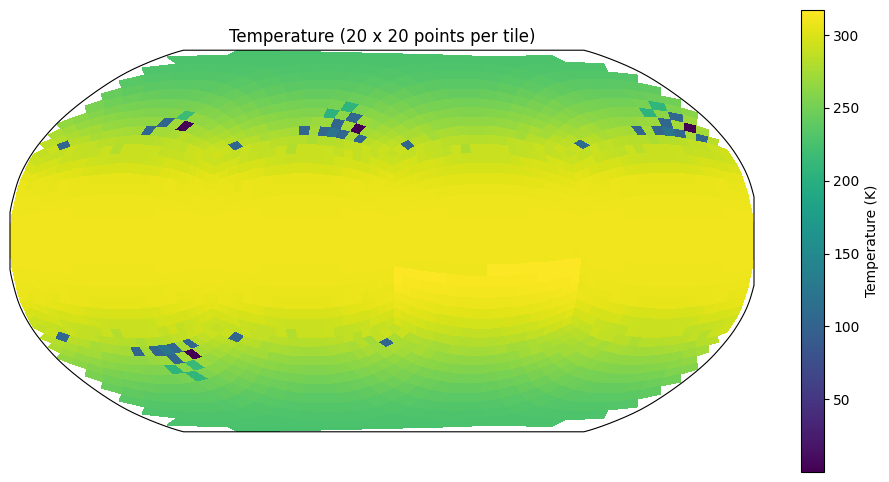

[output:0]

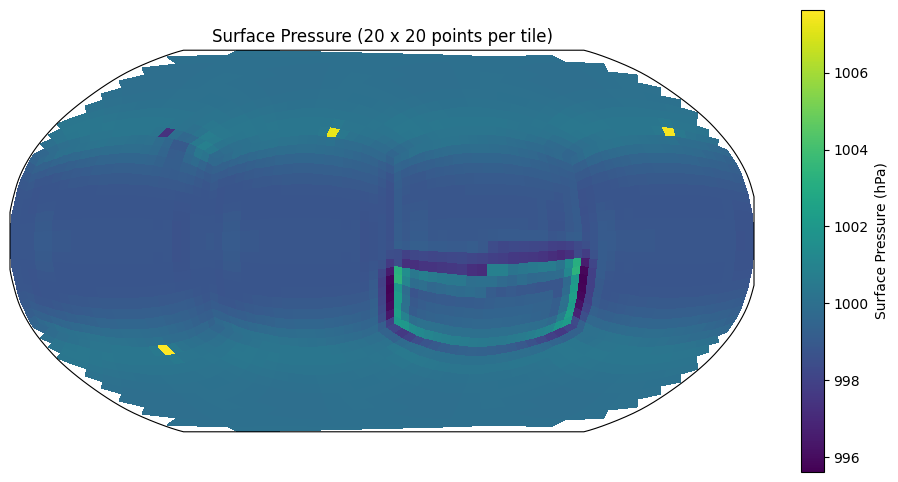

[output:0]

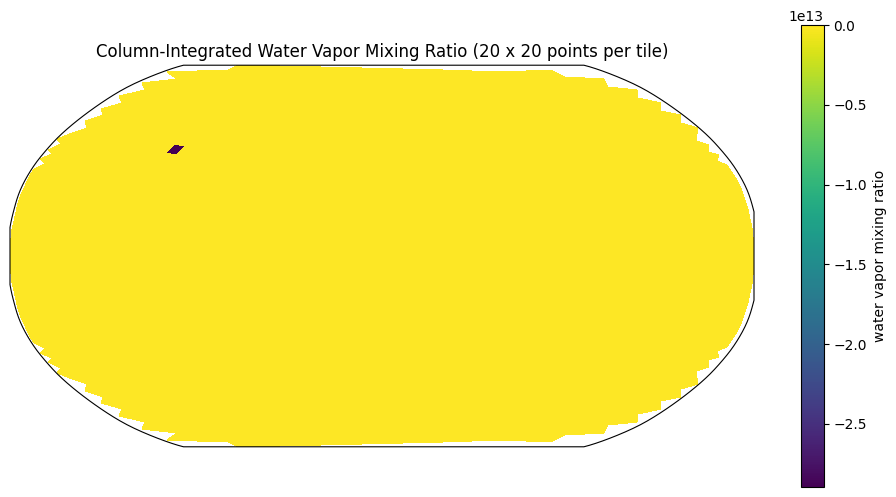

[output:0]

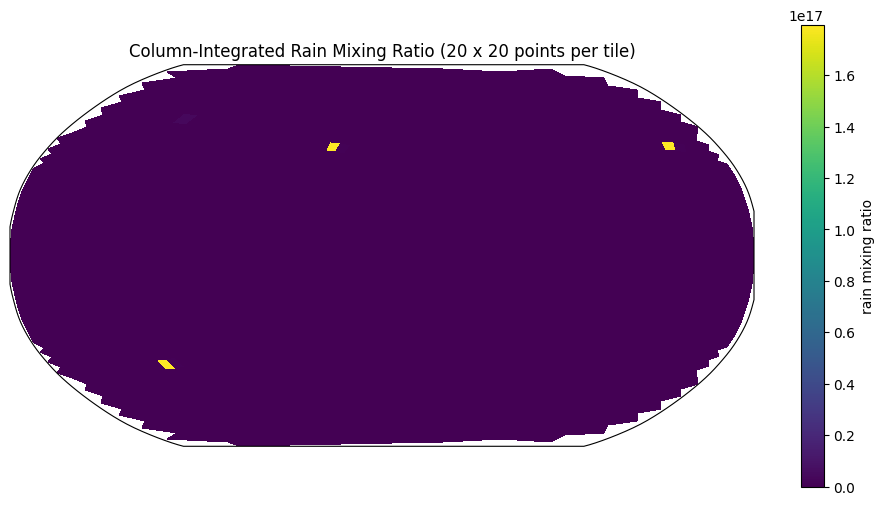

[output:0]

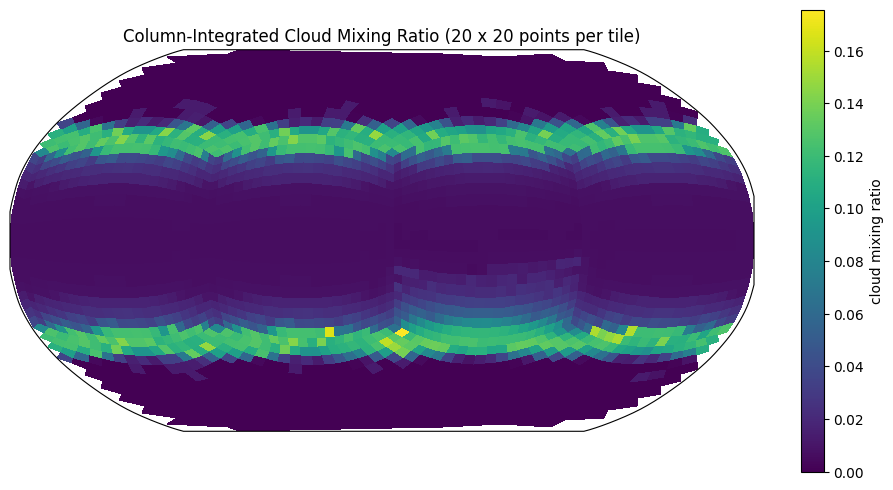

In [11]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    
    u_mean = 0.5 * (u_wind.data[:,:,:-1, :] + u_wind.data[:,:, 1:, :])
    column_qvap = np.sum(qvap, axis=3)/nz
    column_qcld = np.sum(qcld, axis=3)/nz
    column_qrain = np.sum(qrain, axis=3)/nz
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        temperature.data[:, :, :, -2],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Temperature ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_pressure.data[:, :, :]/100.,
        cmap="viridis",
    )
    plt.colorbar(f1, label="Surface Pressure (hPa)")
    ax.set_title(f"Surface Pressure ({nx} x {nx} points per tile)")
    
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qvap,
        cmap="viridis",
    )
    plt.colorbar(f1, label="water vapor mixing ratio")
    ax.set_title(f"Column-Integrated Water Vapor Mixing Ratio ({nx} x {nx} points per tile)")
    

    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qrain,
        cmap="viridis",
    )
    plt.colorbar(f1, label="rain mixing ratio")
    ax.set_title(f"Column-Integrated Rain Mixing Ratio ({nx} x {nx} points per tile)")
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        column_qcld,
        cmap="viridis",
    )
    plt.colorbar(f1, label="cloud mixing ratio")
    ax.set_title(f"Column-Integrated Cloud Mixing Ratio ({nx} x {nx} points per tile)")

[stdout:0] 289.18320381736265


[output:0]

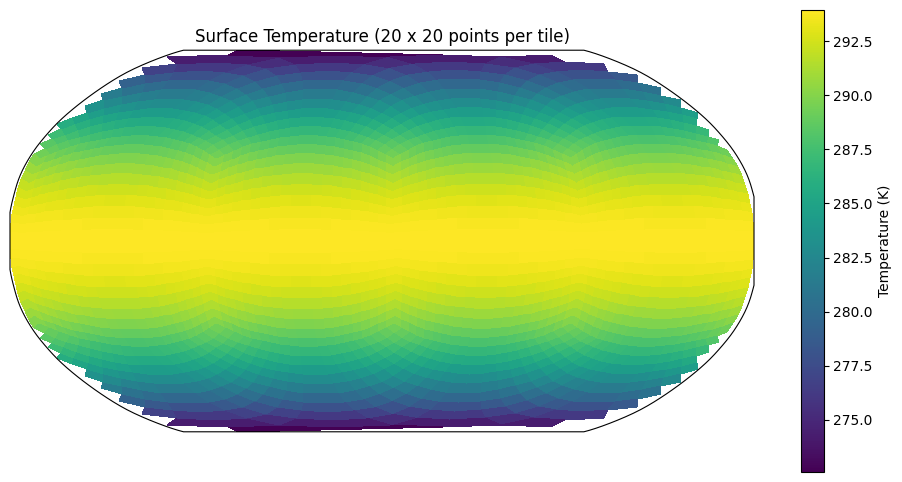

In [12]:
if mpi_rank == 0:
    rotation = -120.
    nx = temperature.shape[1]
    nz = temperature.shape[3]
    print(surface_temperature.field[:].mean())
    
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection=ccrs.Robinson())
    f1 = pcolormesh_cube(
        grid_lat.data * 180./np.pi,
        grid_lon.data * 180./np.pi + rotation,
        surface_temperature.data[:, :, :],
        cmap="viridis",
    )
    plt.colorbar(f1, label="Temperature (K)")
    ax.set_title(f"Surface Temperature ({nx} x {nx} points per tile)")

[stdout:0] 122.45094276426617
300.0


[output:0]

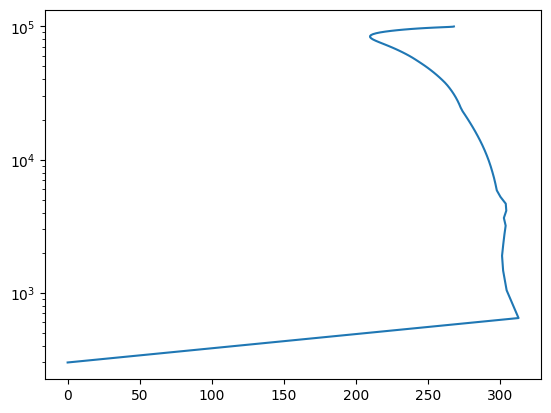

In [22]:
if mpi_rank == 0:
    print(driver.state.radiation_state.tlyr.field.min())
    print(driver.state.radiation_state.prsi.field.min())
    plt.semilogy(driver.state.radiation_state.tlvl.field[3,3,:], driver.state.radiation_state.prsi.field[3,3,::-1])